# BERTopic - Embedding-based Topic Modeling

## 1. Setup & Config

In [17]:
import os

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 42
DATA_PATH = '../data/processed_data/reviews_clean_v2.parquet'
N_SAMPLE = 25_000
EMBED_MODEL = 'all-MiniLM-L6-v2'

## 2. Load Data & Subsample

In [4]:
data = pd.read_parquet(DATA_PATH)

docs = (
    data['review_clean'].sample(N_SAMPLE, random_state = RANDOM_STATE)
    .tolist()
)

print(f'{len(docs):,} reviews sampled')
print(docs[0][:200])

25,000 reviews sampled
grand theft auto....more like grand theft my lifeahahahahahaahaha...ahahaha....eeeehh... i am gunna leave now


## 3. BERTopic Pipeline

### 3.1 Embeddings (Sentence-BERT)

In [5]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer(EMBED_MODEL)
embeddings = embed_model.encode(docs, show_progress_bar = True)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\adris\Desktop\Data_Science_Projects\steam_reviews_nlp\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\adris\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

(25000, 384)


In [6]:
EMB_PATH = '../data/bert_topic_data/bertopic_embeddings.npy'

if os.path.exists(EMB_PATH):
    embeddings = np.load(EMB_PATH)
    print('Loaded cached embeddings')
else:
    embeddings = embed_model.encode(docs, show_progress_bar=True)
    np.save(EMB_PATH, embeddings)
    print('Computed and cached embeddings')

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Computed and cached embeddings


### 3.2 UMAP - Dimensionality Reduction

In [7]:
from umap import UMAP

umap_model = UMAP(
    n_neighbors = 15,      # structure local and global
    n_components = 5,      # dimensions
    min_dist = 0.0,        # pack clusters tightly — helps the downstream HDBSCAN
    metric = 'cosine',     # cosinus for text embedding
    random_state = RANDOM_STATE,
)

### 3.3 HDBSCAN - Clustering

In [8]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size = 100,        # smallest group that counts as a topic
    metric=  'euclidean',          # UMAP output is euclidean-friendly
    cluster_selection_method = 'eom',
    prediction_data=  True,
)

### 3.4 Naming the topics

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words = 'english',        # drop the/and/is — they name no topic
    min_df = 10,                   # ignore very rare words
    ngram_range = (1, 2),          # allow bigrams like "multiplayer mode"
)

## 4. BERTopic Fit

In [10]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model = embed_model,
    umap_model = umap_model,
    hdbscan_model = hdbscan_model,
    vectorizer_model = vectorizer_model,
    calculate_probabilities = False,
    verbose = True
)

In [11]:
topics, probs = topic_model.fit_transform(docs, embeddings = embeddings)

print(f'{len(set(topics))} clusters (including outliers)')

2026-07-18 14:43:52,153 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-18 14:44:29,333 - BERTopic - Dimensionality - Completed ✓
2026-07-18 14:44:29,333 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-18 14:44:33,750 - BERTopic - Cluster - Completed ✓
2026-07-18 14:44:33,762 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 14:44:34,809 - BERTopic - Representation - Completed ✓


45 clusters (including outliers)


## 5. Explore Topic

### 5.1 Topic Reviews

In [14]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,10466,-1_game_nice_play_fun,"[game, nice, play, fun, good, just, like, shot...",[i just ran into a motorcycle club of 9 people...
1,0,1655,0_friends_fun_play friends_play,"[friends, fun, play friends, play, game, buy, ...","[its a fun game to play with friends, such a f..."
2,1,1083,1_10_10 10_naked_rock,"[10, 10 10, naked, rock, follow, killed, game ...","[10/10 vehicular slaughter, 10/10 would unpack..."
3,2,764,2_gta_online_rockstar_story,"[gta, online, rockstar, story, money, single p...","[it's gta v all over again, gta 5 review optim..."
4,3,641,3_good_pretty good_pretty_good good,"[good, pretty good, pretty, good good, ok, lov...","[it's pretty good, pretty good, pretty good d]"
5,4,620,4_bugs_early_early access_access,"[bugs, early, early access, access, game, upda...","[not bad for early access., the game's shotty ..."
6,5,559,5_received free_product received_received_product,"[received free, product received, received, pr...","[product received for free. goood game, produc..."
7,6,546,6_rust_survival_people_game,"[rust, survival, people, game, base, like, pla...","[1v1 me rust, 1v1 me rust you s, rust]"
8,7,506,7_hackers_cheaters_hacker_game,"[hackers, cheaters, hacker, game, hacking, che...",[since another patch. game has now decided tha...
9,8,486,8_gud_dis_m8_game,"[gud, dis, m8, game, da, good, hi, game game, ...","[gud gayme, very gud geim, good verry gud]"


HDBSCAN chose 44 topics plus an outlier bin, with no k set in advance. 

The outlier bin (-1) holds 10,466 reviews, 42 percent of the sample. Its top
words are game, nice, play, fun — the generic "nice game, fun to play" reviews
that fit no specific theme. LDA had to pour these into its ten topics and diluted
them. HDBSCAN says they belong nowhere, which is the more honest read.

Many topics are sharp and game-specific in a way LDA could not reach: GTA Online
(topic 2), cheaters (7), crashes (12), Chinese region-locking (14), and single
games like Monster Hunter, Rocket League, and PUBG each on their own. Topic 9
(mods, modding, mod support) isolates the exact vocabulary leakage flagged back
in Notebook 04.

The finer split has a cost. Some clusters group by style or format, not content.
Topic 8 (gud, dis, m8) is chatspeak. Topics 5 and 16 are both the "product
received free" review disclaimer, split in two. Topic 27 is YouTube URLs. The
embeddings cluster on everything that makes reviews similar — writing style,
boilerplate, format — not just subject. LDA was coarser but would not have handed
back a slang cluster as a topic.

### 5.2 Top words per topic

In [15]:
topic_model.get_topic(2)

[('gta', np.float64(0.06362612366879904)),
 ('online', np.float64(0.03517416530525358)),
 ('rockstar', np.float64(0.01926492108737706)),
 ('story', np.float64(0.019088907681601888)),
 ('money', np.float64(0.01645006802479125)),
 ('single player', np.float64(0.014343970199848463)),
 ('missions', np.float64(0.013991643609214658)),
 ('single', np.float64(0.013726537032604959)),
 ('player', np.float64(0.013469661484441512)),
 ('just', np.float64(0.013352754936314687))]

In [16]:
topic_model.get_representative_docs(2)

["it's gta v all over again",
 'gta 5 review optimization this game has great optimization and runs great on mid to high end pc. i have even seen some people claim they run it ok on a low end pc. all in all they did an amazing job with optimization.story i myself loved the story of gta 5 and it is very interesting. sometimes it gets very funny but other times it can quickly get very brutal as well. i just love the connection between the main protagonists and at times there is a proper drama going on because of the tension between such a different people that are brought together by mere coincidence.gameplay gameplay is absolutely fantastic i love it. it has some cons but i will mention these later. the cars drive great and the shooting and cover mechanics are amazing so its a lot of fun.sounds music and audio in this game are great. rockstar always suprises with how much music is there in the game.cons these are things i personally have a problem with but this doesn\'t mean someone doe

### 5.3 The outlier topic (-1)

In [20]:
outlier_docs = [d for d, t in zip(docs, topics) if t == -1]
print(f'{len(outlier_docs):,} reviews in the outlier bin ({len(outlier_docs)/len(docs):.0%})\n')

for d in outlier_docs[:10]:
    print('—', d[:120])

10,466 reviews in the outlier bin (42%)

— grand theft auto....more like grand theft my lifeahahahahahaahaha...ahahaha....eeeehh... i am gunna leave now
— everytime i switch to trev his eating out of a trash can.
— it is the best game ever it is the best money ive spent on a game and the dlc is great
— so ing gay... yea rather skins than servers.. makes sense right? this
— updated 29/8/16note i've stopped updating this guide because the developers haven't made a decent patch yet.it s now bee
— nice
— insane game!
— this game has its ups and downs considering all of the bugs but it is still a great buy. playing with friends on this ga
— great concept its a shame the bad things about the game are server issues performance and bugs. if they just clean that 
— gameplay a+graphics aco op b+++ compare to late version mhw


### 5.4 UMAP Scatter

In [18]:
umap_2d = UMAP(
    n_neighbors = 15,
    n_components = 2,          # 2D just for plotting
    min_dist = 0.1,            # a little spread reads better
    metric = 'cosine',
    random_state = RANDOM_STATE,
).fit_transform(embeddings)

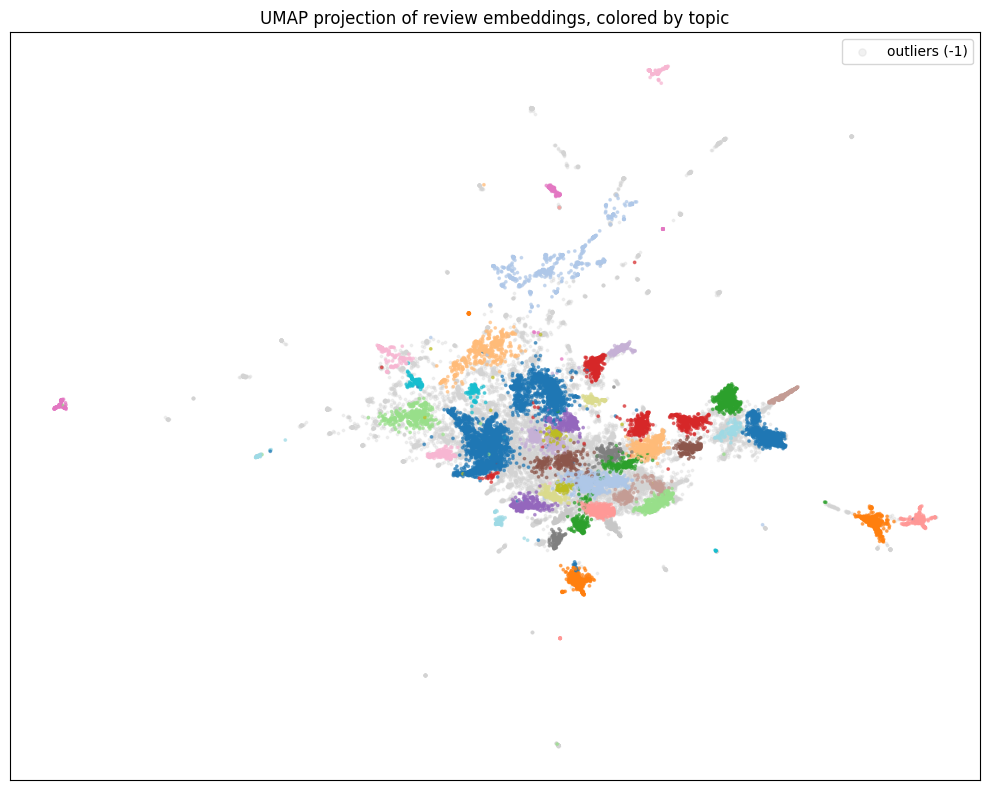

In [19]:
topics_arr = np.array(topics)
outlier = topics_arr == -1

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(umap_2d[outlier, 0], umap_2d[outlier, 1],
           c='lightgray', s=3, alpha=0.3, label='outliers (-1)')
ax.scatter(umap_2d[~outlier, 0], umap_2d[~outlier, 1],
           c=topics_arr[~outlier], cmap='tab20', s=3, alpha=0.6)
ax.set_title('UMAP projection of review embeddings, colored by topic')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper right', markerscale=3)
plt.tight_layout()
plt.show()

The gray haze across the center is the 42 percent outlier bin.
The coloured islands are the topics: the tight, isolated ones at the edges are the sharpest, while the overlapping blobs in the middle are topics that sit close in language.
The view is a 2D approximation of the 5D clustering space, so it illustrates rather than proves.

## 6. Conclusions

BERTopic ran the full pipeline on 25k reviews: Sentence-BERT embeddings, UMAP
reduction, HDBSCAN clustering, c-TF-IDF naming. HDBSCAN chose 44 topics on its
own, against the ten LDA was told to find in Notebook 03.

Two things stood out. HDBSCAN left 42 percent of reviews in an outlier bin
instead of forcing every generic "good game" into a topic — honest where LDA was
tidy. And the topics it did find were sharper: single games, region-locking,
cheating, the modding thread from Notebook 04, each on its own.

The cost of that sharpness: some clusters group by style or format, not content —
chatspeak, the "product received free" disclaimer, bare URLs. The embeddings
cluster on everything that makes reviews similar, not just subject.

As an exercise this showed the shift from count-based to embedding-based topic
modeling end to end. Tuning min_cluster_size, reducing outliers, or merging the
style clusters would be the next steps for a serious run.